In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║           baseline_models.ipynb                                          ║
# ║           Baseline Model Evaluation — QB Passing Predictions             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ─── 0. Imports & Setup ─────────────────────────────────────────────────────
"""
Standard imports, path setup, logging configuration
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import logging
import joblib
from datetime import datetime

from sklearn.impute import SimpleImputer

# Path setup so src modules are importable from notebook
sys.path.append(str(Path.cwd().parent.parent))

from src import configurations as cfg
from src.models.base_models import NaivePersistenceModel, RidgeRegressionModel
from src.evaluation.metrics import (
    evaluate, compare_models, baseline_improvement,
    per_player_errors, prediction_summary
)

# Setup logging
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

In [2]:
# ─── 1. Train / Test Split ──────────────────────────────────────────────────
"""
Load the dataset and perform a manual split for baseline evaluation:
    Train: 2018-2023
    Test:  2024
"""

# Load the dataset
df_features = pd.read_csv(
    Path.cwd().parent.parent / "src" / "data" / 
    cfg.QB_OUTPUT_FEATURES_FILE.replace("{start}", "2018").replace("{end}", "2025")
)

# Perform manual split
df_train = df_features[(df_features['season'] <= 2023)]
df_test = df_features[df_features['season'] == 2024]

# Print row counts for train and test to confirm
logger.info(f"Train rows: {df_train.shape[0]}")
logger.info(f"Test rows: {df_test.shape[0]}")

2026-05-12 20:01:21,511 - INFO - Train rows: 241
2026-05-12 20:01:21,512 - INFO - Test rows: 37


In [ ]:
# ─── 2. Feature Preparation ─────────────────────────────────────────────────
"""
Collect feature/target data for both training and test sets.
Impute missing values in the feature data.
"""

target_cols = list(cfg.QB_TARGET_COLS.values())

# Select features and targets
training_features = df_train[cfg.QB_FEATURE_COLS].copy()
training_targets = df_train[target_cols].copy()
test_features = df_test[cfg.QB_FEATURE_COLS].copy()
test_targets = df_test[target_cols].copy()

# Fit median imputer on training features - apply same to test
imputer = SimpleImputer(strategy="median")
training_features = pd.DataFrame(
    imputer.fit_transform(training_features),
    columns=cfg.QB_FEATURE_COLS,
    index=df_train.index
)
test_features = pd.DataFrame(
    imputer.transform(test_features),
    columns=cfg.QB_FEATURE_COLS,
    index=df_test.index
)

# Save imputer for inference pipeline
joblib.dump(imputer, Path.cwd().parent / cfg.CHECKPOINT_DIR / "qb_imputer.pkl")

# Verify no NaN values remain in features after imputation
assert not np.isnan(training_features).values.any(), "NaN values found in training features"
assert not np.isnan(test_features).values.any(), "NaN values found in test features"

# Print feature shape
logger.info(f"Training features shape: {training_features.shape}")
logger.info(f"Test features shape:     {test_features.shape}")
logger.info(f"Training targets shape:  {training_targets.shape}")
logger.info(f"Test targets shape:      {test_targets.shape}")

2026-05-12 20:01:21,549 - INFO - Training features shape: (241, 36)
2026-05-12 20:01:21,550 - INFO - Test features shape:     (37, 36)
2026-05-12 20:01:21,551 - INFO - Training targets shape:  (241, 6)
2026-05-12 20:01:21,552 - INFO - Test targets shape:      (37, 6)


In [4]:
# ─── 3. Baseline 1 — Naive Persistence ──────────────────────────────────────
"""
Capture and evaluate predictions via Naive Persistence Model
"""

logger.info("Evaluating Naive Persistence Model")

# Model instantiation
model = NaivePersistenceModel(
    target_cols=list(cfg.QB_TARGET_COLS.values()),
    source_col_map={v: k for k, v in cfg.QB_TARGET_COLS.items()}
)

# Generate predictions on test set
predictions = model.predict(df_test)

# Evaluate the model
df_metrics_persistence = evaluate(df_test, predictions, model.target_cols)

# Print the metrics table
print(f"{df_metrics_persistence}\n")

summary = prediction_summary(
    df_test,
    predictions,
    model.target_cols
)

print(summary.sort_values("abs_error", ascending=False).head(20).to_string())

2026-05-12 20:01:21,568 - INFO - Evaluating Naive Persistence Model


       target         rmse          mae        r2
0  target_att   173.991301   135.189189 -0.052299
1  target_cmp   119.283446    93.189189 -0.161907
2    target_g     4.776066     3.459459 -0.118001
3  target_int     4.655714     3.567568 -0.351891
4   target_td    11.600326     9.054054 -0.251243
5  target_yds  1384.450140  1073.594595 -0.140288

               player  season      target  actual  predicted   error  abs_error
107        Joe Burrow    2024  target_yds  1809.0     4918.0 -3109.0     3109.0
149      Kyler Murray    2024  target_yds   962.0     3851.0 -2889.0     2889.0
53       Dak Prescott    2024  target_yds  4552.0     1978.0  2574.0     2574.0
77    Jacoby Brissett    2024  target_yds  3366.0      826.0  2540.0     2540.0
101    Jayden Daniels    2024  target_yds  1262.0     3568.0 -2306.0     2306.0
65         Drake Maye    2024  target_yds  4394.0     2276.0  2118.0     2118.0
209   Trevor Lawrence    2024  target_yds  4007.0     2045.0  1962.0     1962.0
143      

In [5]:
# ─── 4. Baseline 2 — Ridge Regression ───────────────────────────────────────
"""
Capture and evaluate predictions via Ridge Regression Model
"""

logger.info("Evaluating Ridge Regression Model")

# Model instantiation
model = RidgeRegressionModel(
    target_cols=list(cfg.QB_TARGET_COLS.values()),
    feature_cols=cfg.QB_FEATURE_COLS,
    alpha=cfg.ALPHA
)

# Fit on training set
model.fit(df_train)

# Generate predictions on test set
predictions = model.predict(df_test)

# Evaluate with evaluate()
df_metrics_ridge = evaluate(df_test, predictions, model.target_cols)

# Print metrics table
print(f"{df_metrics_ridge}\n")

summary = prediction_summary(
    df_test, 
    predictions, 
    model.target_cols
)

print(summary.sort_values(by="abs_error", ascending=False).head(20).to_string())

2026-05-12 20:01:21,639 - INFO - Evaluating Ridge Regression Model


       target         rmse         mae        r2
0  target_att   148.030093  123.889856  0.238299
1  target_cmp    97.352801   80.430424  0.226059
2    target_g     3.955765    3.418580  0.233058
3  target_int     3.839211    3.268402  0.080709
4   target_td     8.757712    6.837388  0.286847
5  target_yds  1147.073078  936.045410  0.217216

               player  season      target  actual    predicted        error    abs_error
101    Jayden Daniels    2024  target_yds  1262.0  3282.200117 -2020.200117  2020.200117
65         Drake Maye    2024  target_yds  4394.0  2442.553860  1951.446140  1951.446140
77    Jacoby Brissett    2024  target_yds  3366.0  1459.860415  1906.139585  1906.139585
53       Dak Prescott    2024  target_yds  4552.0  2656.174259  1895.825741  1895.825741
149      Kyler Murray    2024  target_yds   962.0  2820.041812 -1858.041812  1858.041812
107        Joe Burrow    2024  target_yds  1809.0  3655.585163 -1846.585163  1846.585163
191    Russell Wilson    2024  ta

In [6]:
# ─── 5. Model Comparison ────────────────────────────────────────────────────
"""
Compare the performance of the two models
"""

logger.info("Comparing Model Performance")

# Compare the performance of the two models
comparison_dict = {
    "persistence": df_metrics_persistence,
    "ridge": df_metrics_ridge
}
df_comparison = compare_models(comparison_dict)

# Evaluate the improvement of ridge over persistence
df_improvement = baseline_improvement(df_metrics_persistence, df_metrics_ridge)

print(df_comparison)
print(df_improvement)

2026-05-12 20:01:21,735 - INFO - Comparing Model Performance


       target         rmse                                  mae              \
               persistence        ridge best_model  persistence       ridge   
0  target_att   173.991301   148.030093      ridge   135.189189  123.889856   
1  target_cmp   119.283446    97.352801      ridge    93.189189   80.430424   
2    target_g     4.776066     3.955765      ridge     3.459459    3.418580   
3  target_int     4.655714     3.839211      ridge     3.567568    3.268402   
4   target_td    11.600326     8.757712      ridge     9.054054    6.837388   
5  target_yds  1384.450140  1147.073078      ridge  1073.594595  936.045410   

                      r2                       
  best_model persistence     ridge best_model  
0      ridge   -0.052299  0.238299      ridge  
1      ridge   -0.161907  0.226059      ridge  
2      ridge   -0.118001  0.233058      ridge  
3      ridge   -0.351891  0.080709      ridge  
4      ridge   -0.251243  0.286847      ridge  
5      ridge   -0.140288  0.217

2026-05-12 20:01:21,781 - INFO - Analyzing Ridge Coefficients


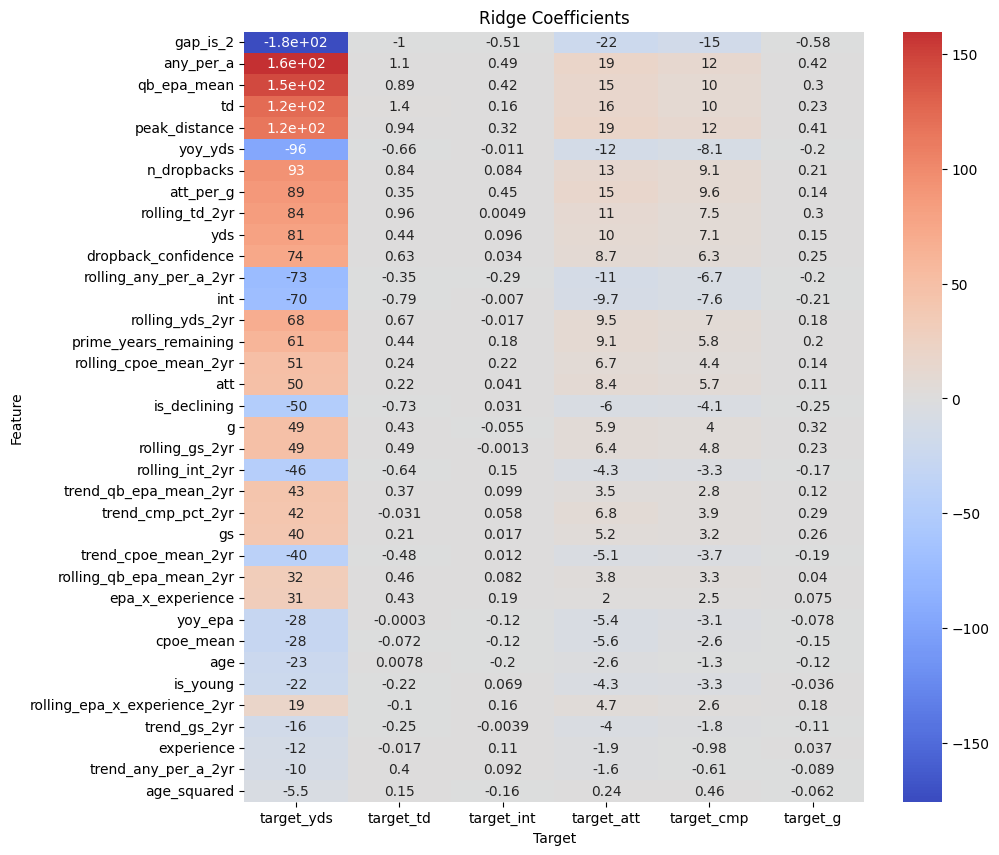

In [7]:
# ─── 6. Ridge Coefficient Analysis ──────────────────────────────────────────
"""
Call get_coefficients() on fitted ridge model.
Visualize as a heatmap — features as rows, targets as columns
"""

logger.info("Analyzing Ridge Coefficients")

df_coeffs = model.get_coefficients()

# Visualize the coefficients as a heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(df_coeffs, annot=True, cmap="coolwarm", center=0)
plt.title("Ridge Coefficients")
plt.xlabel("Target")
plt.ylabel("Feature")

# Download the heatmap as a PNG file
now  = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"../data/processed/base_models/qb/ridge_coefficients_{now}.png", dpi=300, bbox_inches='tight')

plt.show()

In [8]:
# ─── 7. Prediction Spot Check ───────────────────────────────────────────────
"""
Use prediction_summary() to look at actual vs predicted for 2024.
Filter to well-known QBs for easy sanity checking
"""

logger.info("Performing Spot Check on Predictions")

for player in ['Patrick Mahomes', 'Josh Allen', 'Joe Burrow', 'Lamar Jackson', 'Jalen Hurts']:
    df_player = df_test[df_test['player'] == player]
    df_summary = prediction_summary(df_player, predictions, model.target_cols)
    print(f"Summary for {player}:")
    print(f"{df_summary}\n")

2026-05-12 20:01:24,156 - INFO - Performing Spot Check on Predictions


Summary for Patrick Mahomes:
            player  season      target  actual    predicted       error  \
0  Patrick Mahomes    2024  target_att   502.0   481.971299   20.028701   
1  Patrick Mahomes    2024  target_cmp   315.0   320.226919   -5.226919   
2  Patrick Mahomes    2024    target_g    14.0    14.716686   -0.716686   
3  Patrick Mahomes    2024  target_int    11.0     9.719524    1.280476   
4  Patrick Mahomes    2024   target_td    22.0    22.354365   -0.354365   
5  Patrick Mahomes    2024  target_yds  3587.0  3485.631161  101.368839   

    abs_error  
0   20.028701  
1    5.226919  
2    0.716686  
3    1.280476  
4    0.354365  
5  101.368839  

Summary for Josh Allen:
       player  season      target  actual    predicted       error   abs_error
0  Josh Allen    2024  target_att   460.0   515.915693  -55.915693   55.915693
1  Josh Allen    2024  target_cmp   319.0   347.644362  -28.644362   28.644362
2  Josh Allen    2024    target_g    17.0    15.850096    1.149904    1

In [9]:
# ─── 8. Per-Player Error Analysis ───────────────────────────────────────────
"""
Use per_player_errors() to find hardest-to-predict QBs per-target
"""

logger.info("Analyzing Per-Player Errors")

df_errors = per_player_errors(df_test, predictions, model.target_cols)

# For each target, find the players with the highest errors
for target in model.target_cols:
    print(f"Top 10 players with highest {target} errors:")
    print(df_errors[df_errors['target'] == target].sort_values('mae', ascending=False).head(10))
    print("\n")

2026-05-12 20:01:24,225 - INFO - Analyzing Per-Player Errors


Top 10 players with highest target_yds errors:
             player      target         rmse          mae   r2  n
0    Jayden Daniels  target_yds  2020.200117  2020.200117  0.0  1
1        Drake Maye  target_yds  1951.446140  1951.446140  0.0  1
2   Jacoby Brissett  target_yds  1906.139585  1906.139585  0.0  1
3      Dak Prescott  target_yds  1895.825741  1895.825741  0.0  1
4      Kyler Murray  target_yds  1858.041812  1858.041812  0.0  1
5        Joe Burrow  target_yds  1846.585163  1846.585163  0.0  1
6    Russell Wilson  target_yds  1827.975007  1827.975007  0.0  1
7     Lamar Jackson  target_yds  1619.094535  1619.094535  0.0  1
8  Matthew Stafford  target_yds  1553.071073  1553.071073  0.0  1
9       Cooper Rush  target_yds  1541.689880  1541.689880  0.0  1


Top 10 players with highest target_td errors:
               player     target       rmse        mae   r2  n
96   Matthew Stafford  target_td  23.644900  23.644900  0.0  1
101        Drake Maye  target_td  16.498125  16.49812

In [10]:
# ─── 9. Alpha Sensitivity Analysis ─────────────────────────────────────────
"""
Try Ridge with multiple alpha values to see sensitivity
"""

logger.info("Conducting Alpha Sensitivity Analysis")

df_combined = pd.DataFrame()

for alpha in [1.0, 10.0, 100.0, 500.0, 1000.0]:
    # Model instantiation
    model_sensitivity = RidgeRegressionModel(
        target_cols=list(cfg.QB_TARGET_COLS.values()),
        feature_cols=cfg.QB_FEATURE_COLS,
        alpha=alpha
    )

    # Fit on training set
    model_sensitivity.fit(df_train)

    # Generate predictions on test set
    predictions = model_sensitivity.predict(df_test)

    # Evaluate with evaluate()
    df_metrics_ridge = evaluate(df_test, predictions, model_sensitivity.target_cols)

    # Print metrics table
    print(f"Testing alpha = {alpha}")
    print(f"{df_metrics_ridge}\n")

    # Append alpha value to each row in the metrics dataframe
    df_metrics_ridge['alpha'] = alpha

    # Combine tables and save as csv
    df_combined = pd.concat([df_combined, df_metrics_ridge], ignore_index=True)

df_combined.to_csv(f"../data/processed/base_models/qb/ridge_alpha_sensitivity_{now}.csv", index=False)


2026-05-12 20:01:24,579 - INFO - Conducting Alpha Sensitivity Analysis


Testing alpha = 1.0
       target         rmse         mae        r2
0  target_att   146.943239  125.262102  0.249443
1  target_cmp    96.863950   81.050698  0.233812
2    target_g     4.173379    3.411154  0.146356
3  target_int     3.872481    3.243004  0.064707
4   target_td     9.132741    7.103863  0.224461
5  target_yds  1139.961390  943.679554  0.226892

Testing alpha = 10.0
       target         rmse         mae        r2
0  target_att   146.818573  124.537645  0.250716
1  target_cmp    96.692952   80.285780  0.236515
2    target_g     4.051819    3.401451  0.195360
3  target_int     3.885791    3.257637  0.058267
4   target_td     8.892645    6.831423  0.264702
5  target_yds  1139.963961  936.189680  0.226889

Testing alpha = 100.0
       target         rmse         mae        r2
0  target_att   148.030093  123.889856  0.238299
1  target_cmp    97.352801   80.430424  0.226059
2    target_g     3.955765    3.418580  0.233058
3  target_int     3.839211    3.268402  0.080709
4   

2026-05-12 20:01:24,824 - INFO - Conducting Residual Analysis


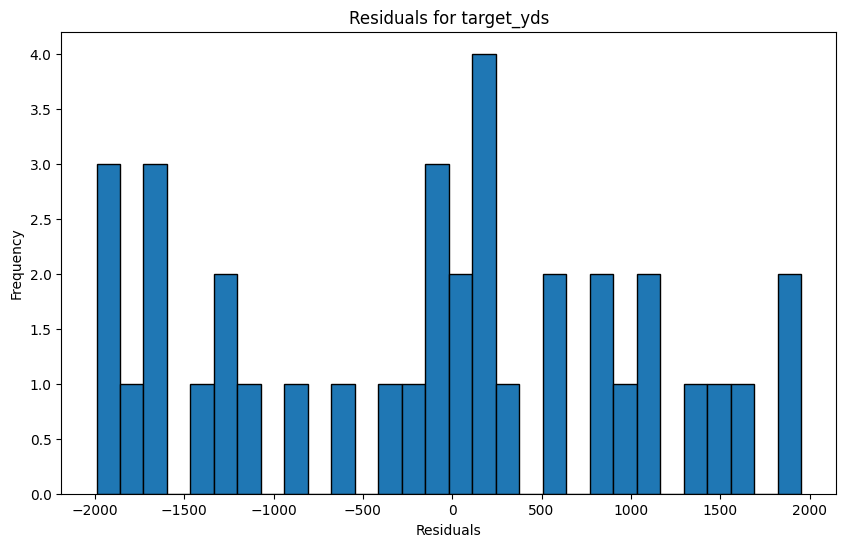

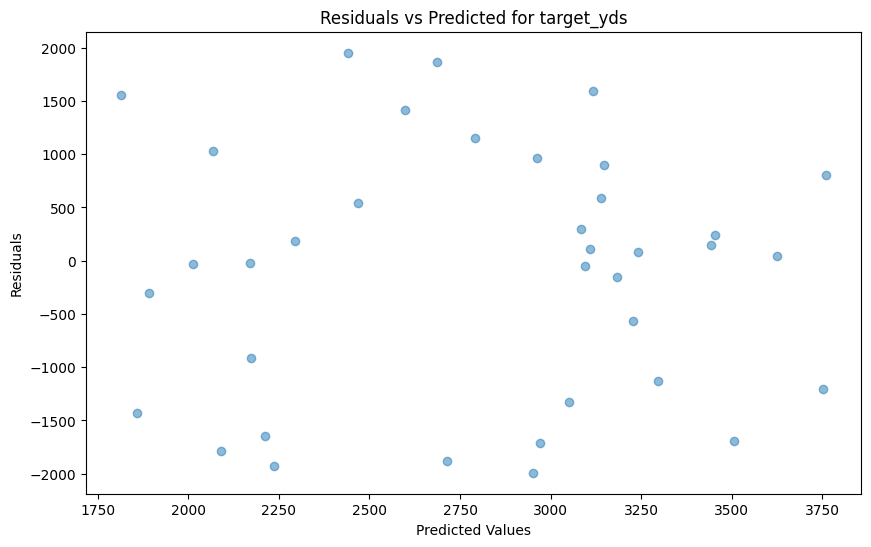

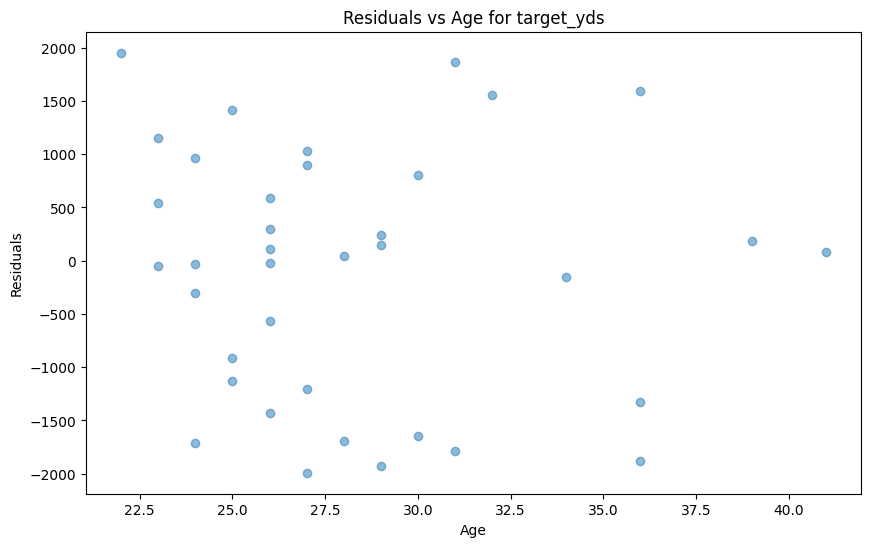

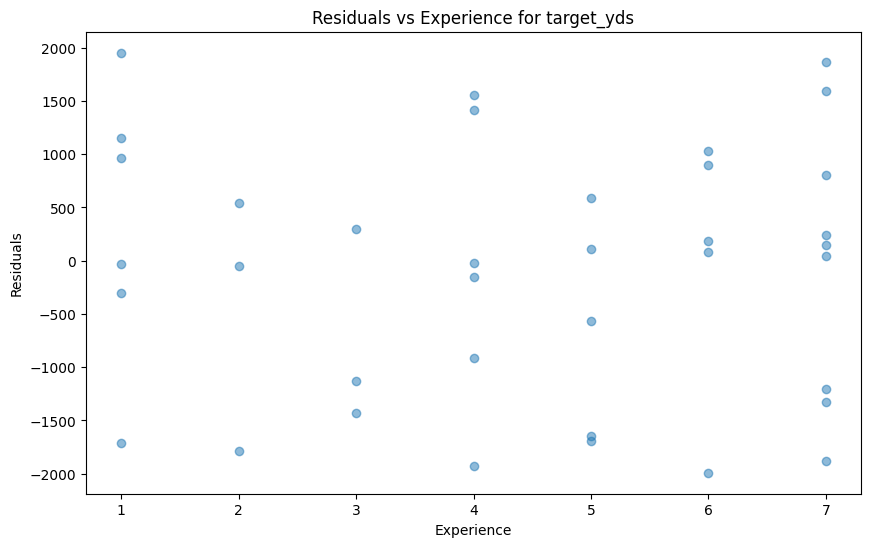

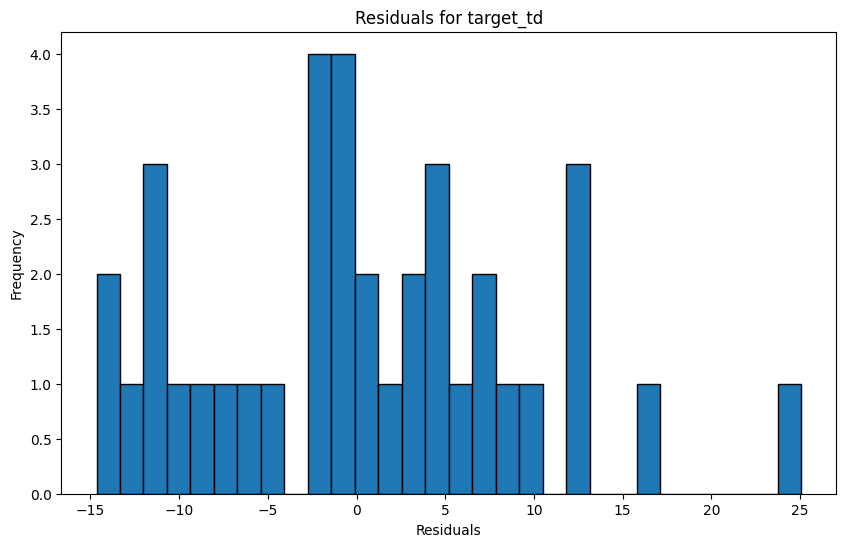

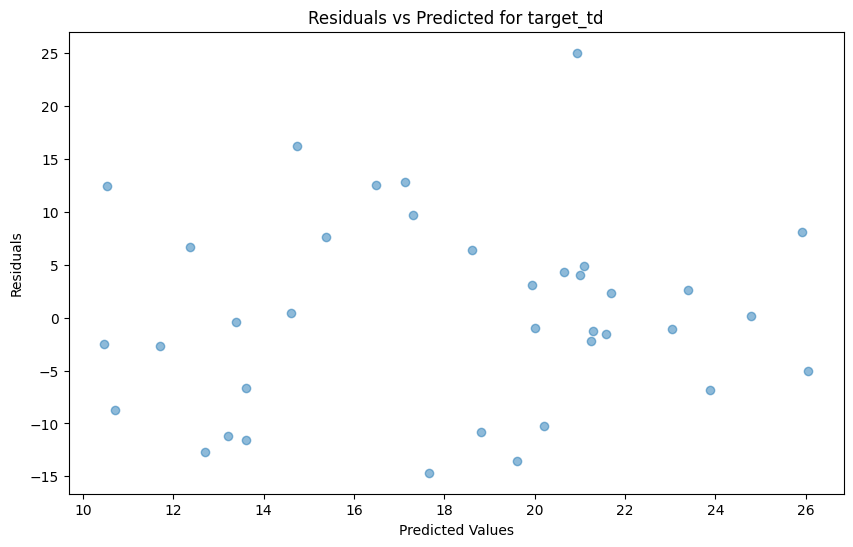

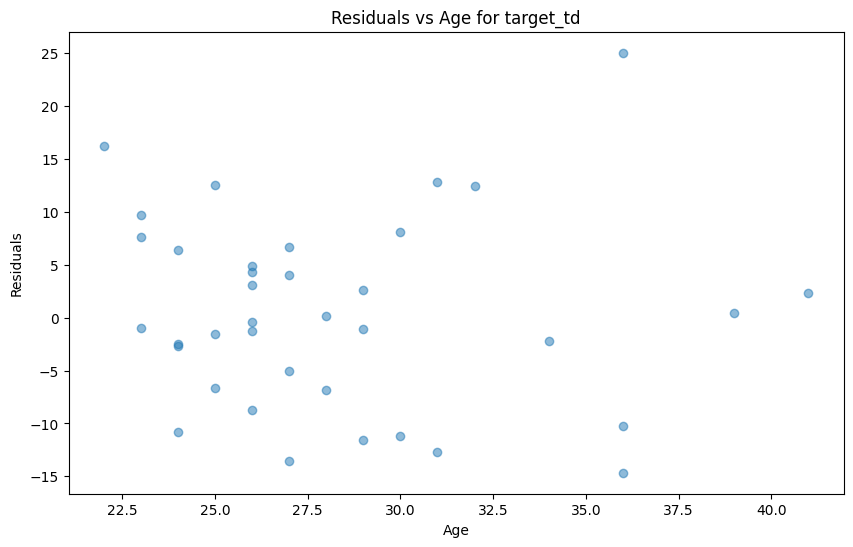

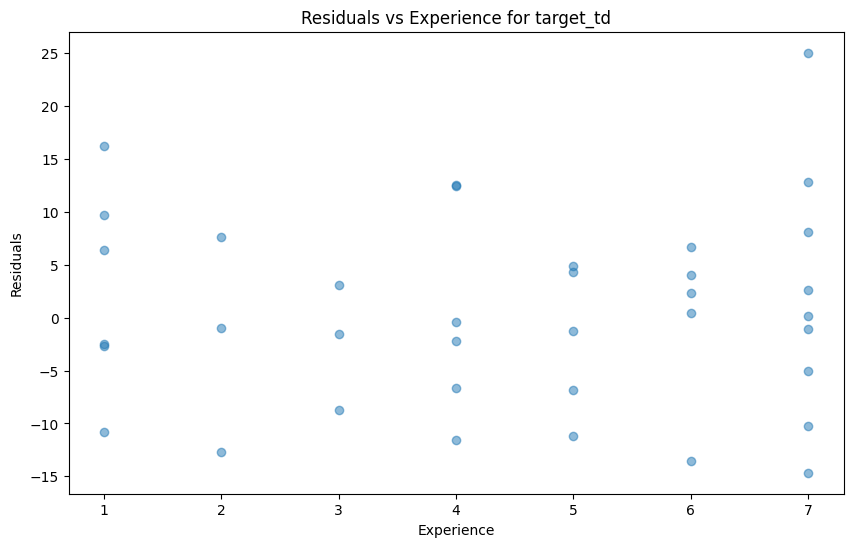

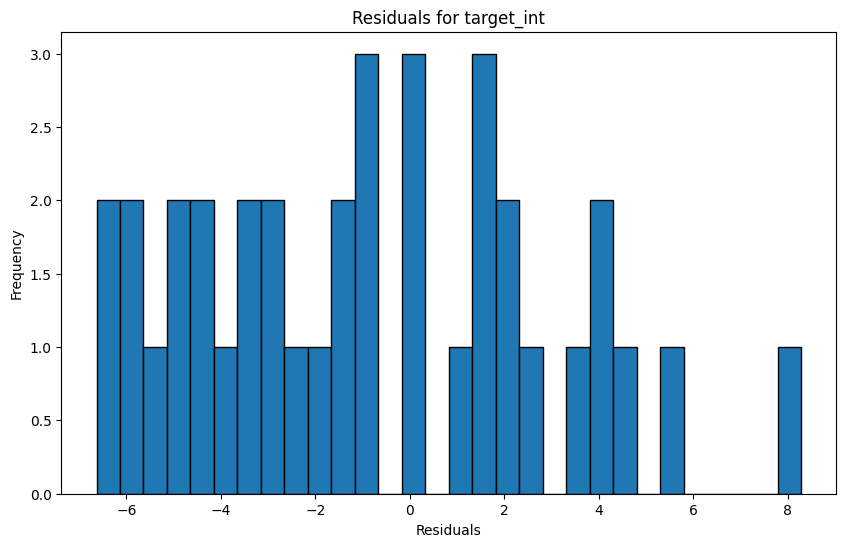

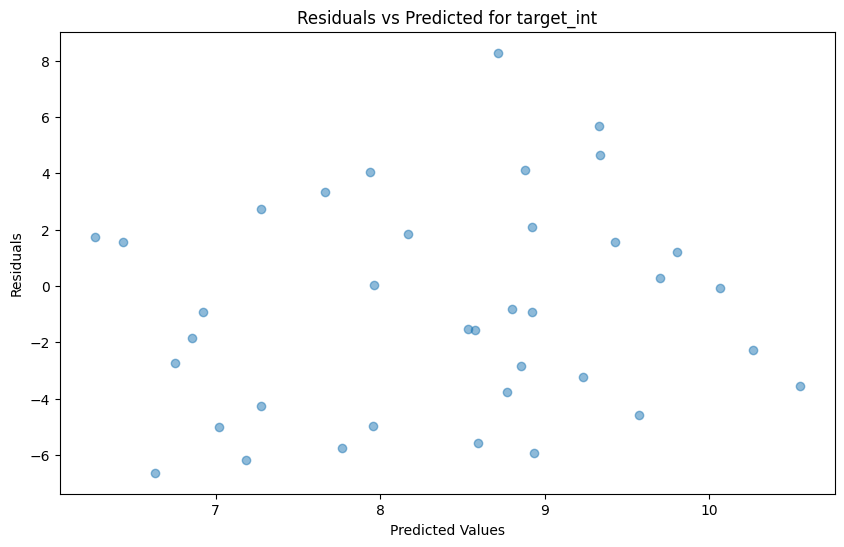

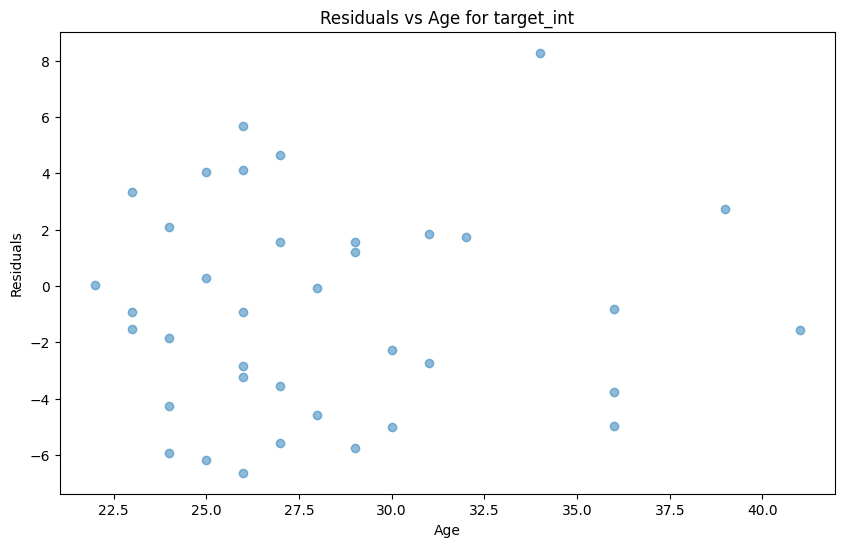

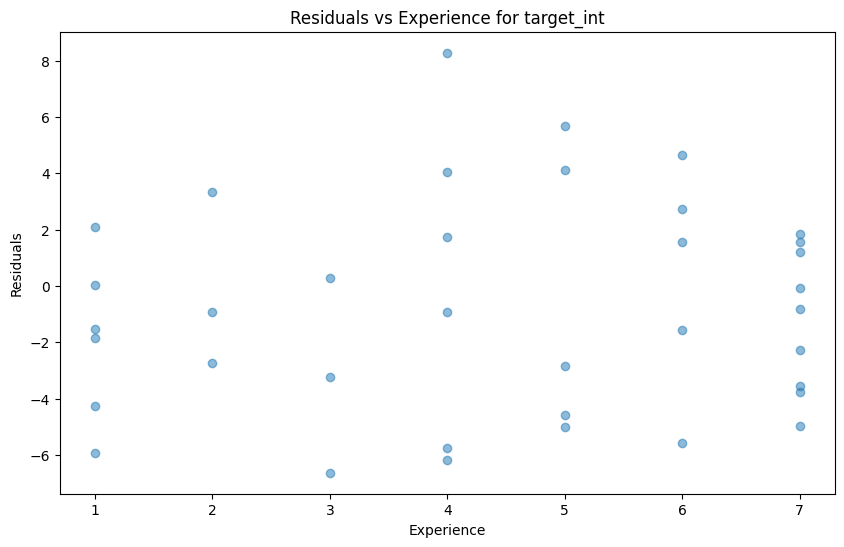

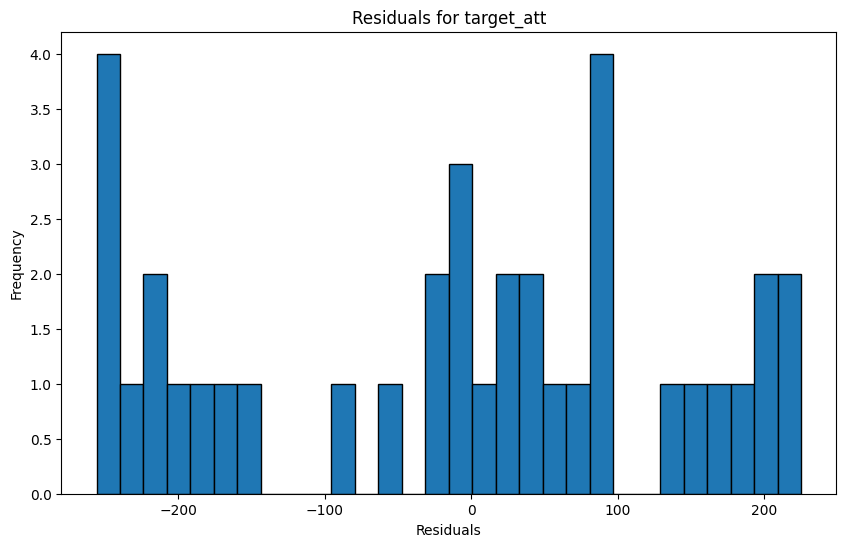

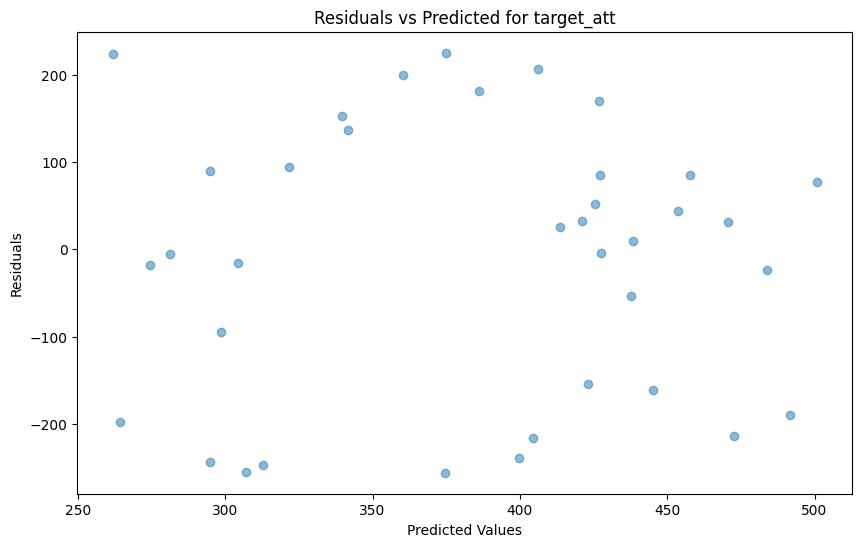

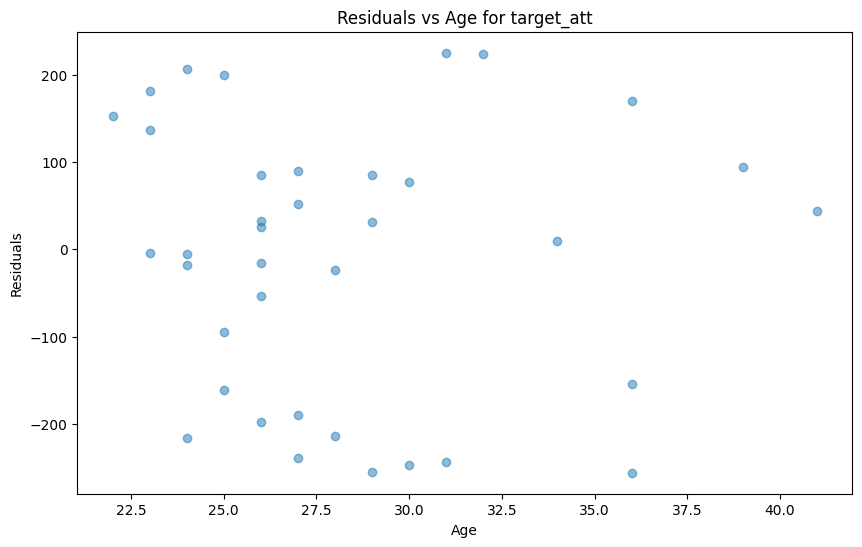

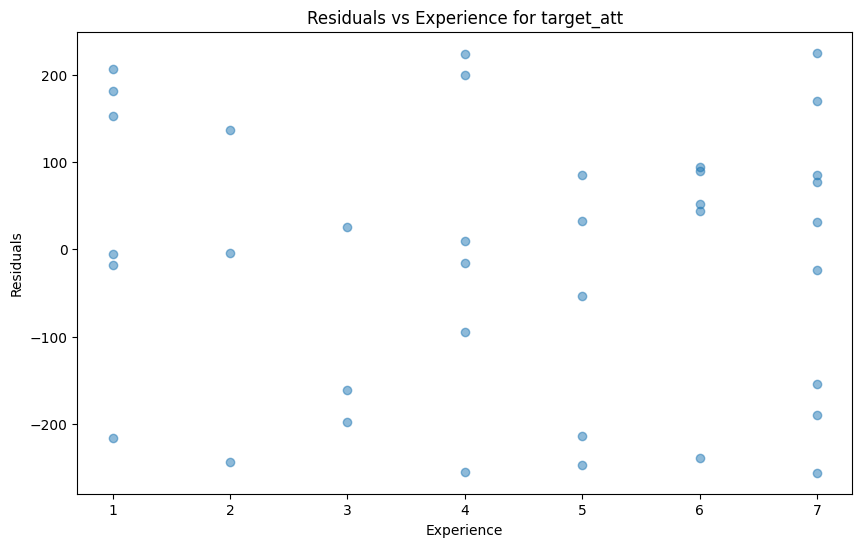

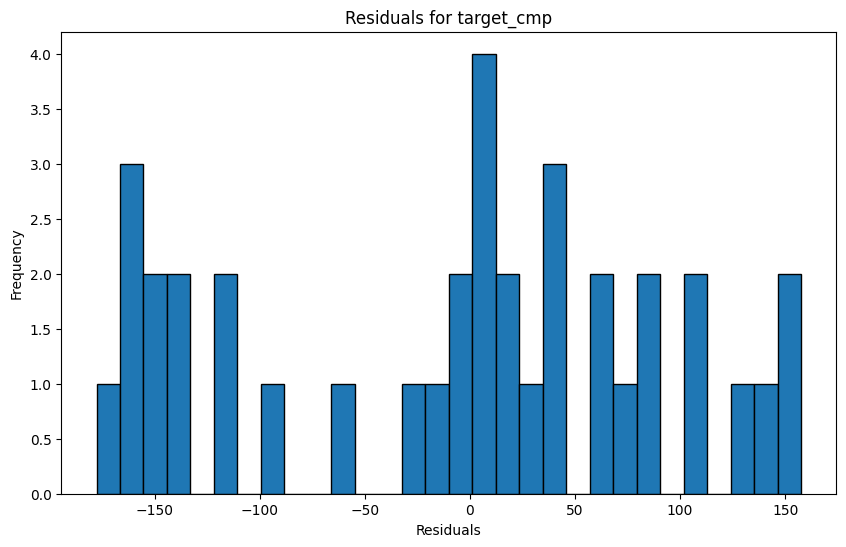

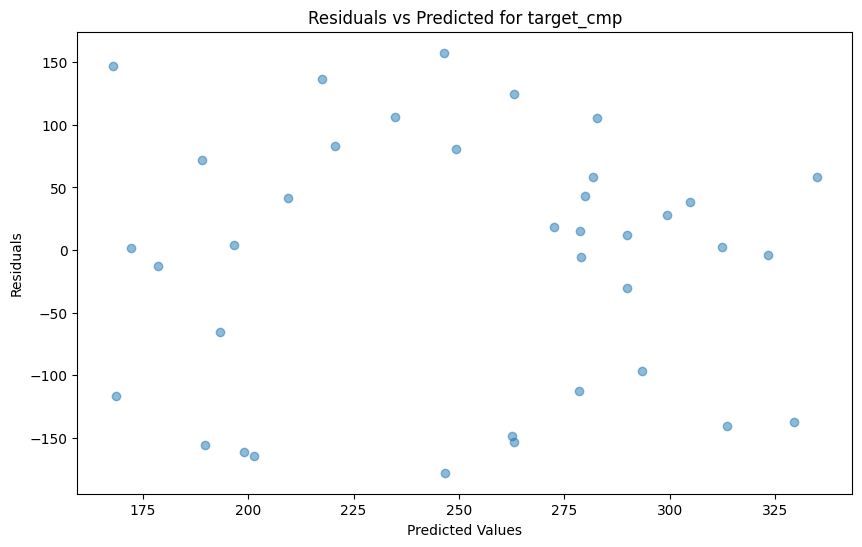

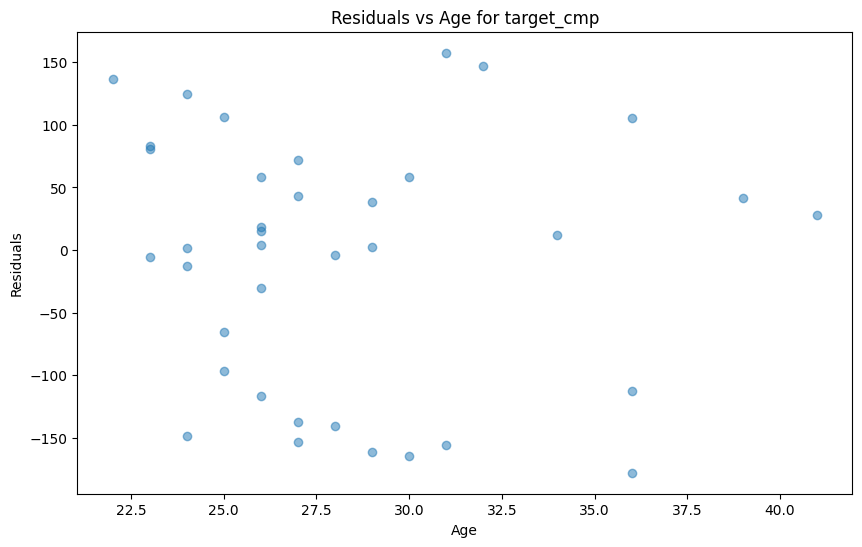

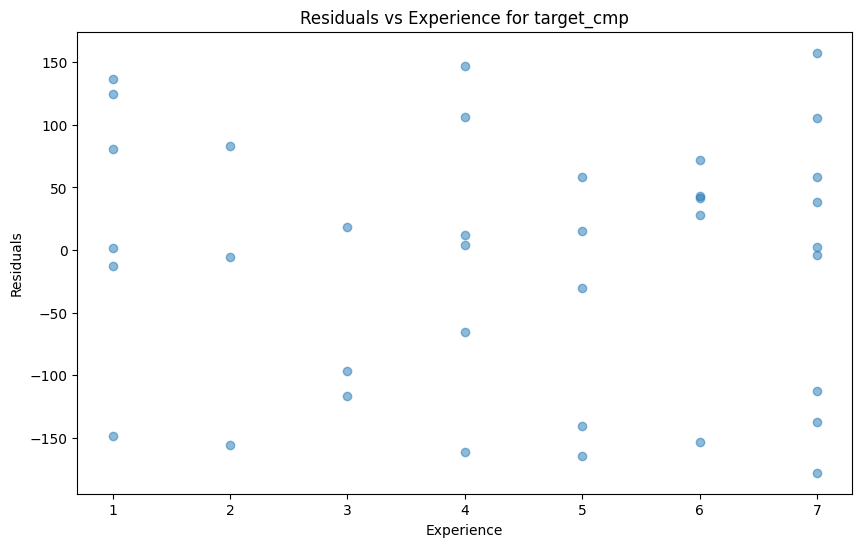

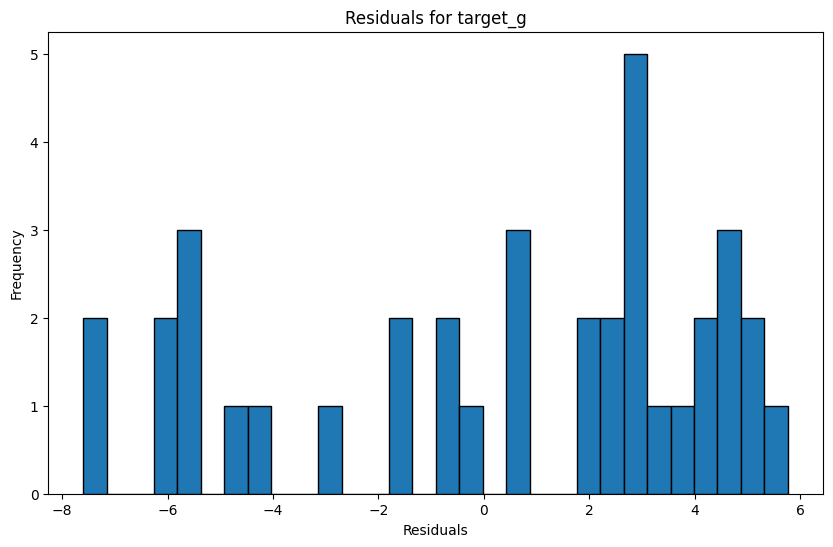

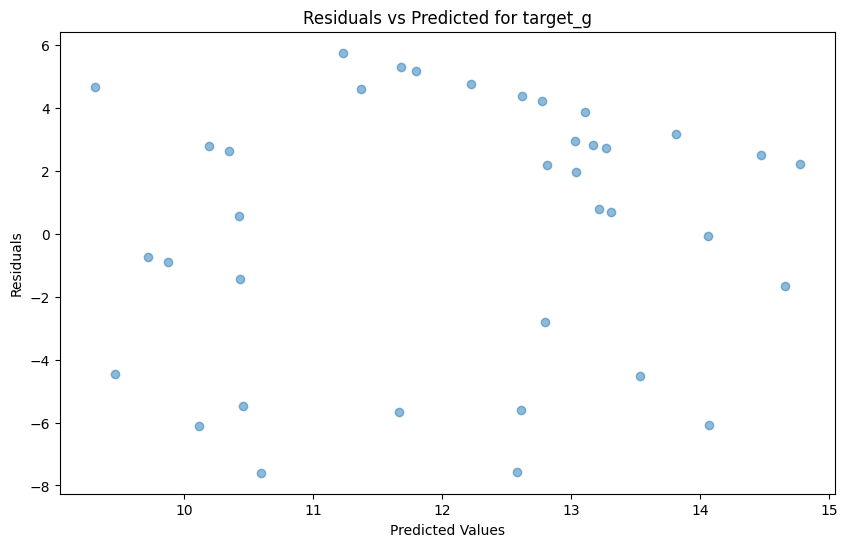

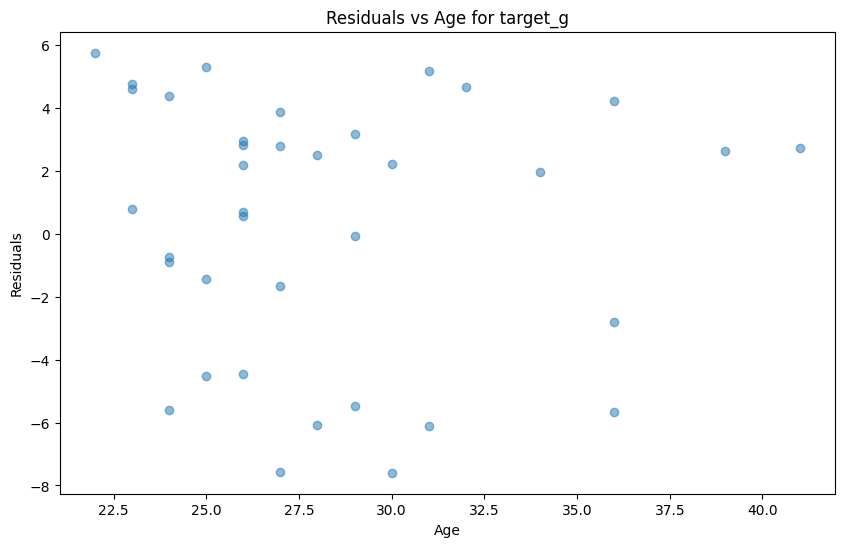

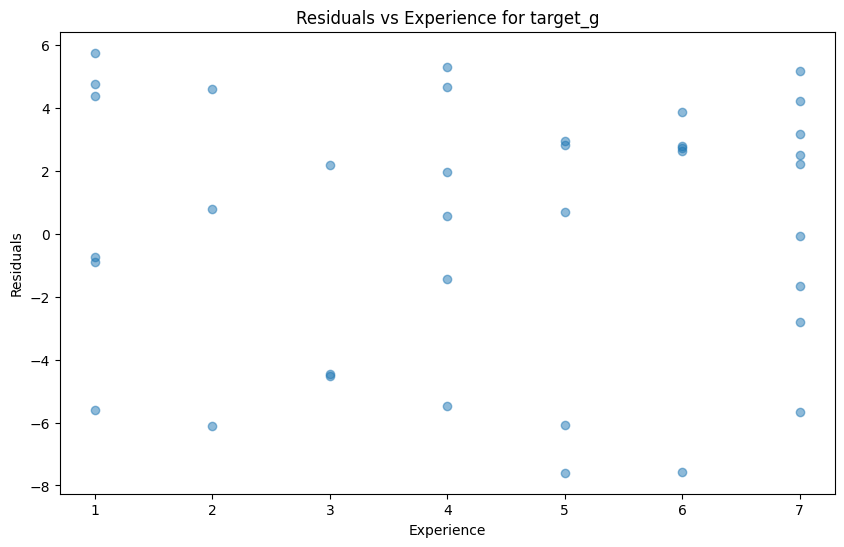

In [ ]:
# ─── 10. Residual Analysis ──────────────────────────────────────────────────
"""
Plot residuals (actual - predicted) for each target
"""

logger.info("Conducting Residual Analysis")

for target in model.target_cols:
    # Calculate residuals
    residuals = df_test[target] - predictions[target]

    # Plot the residuals as a histogram
    plt.figure(figsize=(10, 6))
    plt.hist(residuals, bins=30, edgecolor='black')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title(f'Residuals for {target}')
    plt.show()

    # Plot the residuals against the predicted values
    plt.figure(figsize=(10, 6))
    plt.scatter(predictions[target], residuals, alpha=0.5)
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Predicted for {target}')
    plt.show()

    # Plot the residuals against the player's age
    plt.figure(figsize=(10, 6))
    plt.scatter(df_test['age'], residuals, alpha=0.5)
    plt.xlabel('Age')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Age for {target}')
    plt.show()

    # Plot the residuals against the player's experience
    plt.figure(figsize=(10, 6))
    plt.scatter(df_test['experience'], residuals, alpha=0.5)
    plt.xlabel('Experience')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Experience for {target}')
    plt.show()